# Diagramas de arquitectura del modelo convolucional 1D v2 (U-Net residual)

Figuras de la arquitectura del modelo entrenado en `cnn-v2_training.ipynb`, para la memoria. Las dibuja `services/architecture_diagram.py`, el módulo que comparten todos los cuadernos de diagramas de `models`:

- La vista `graph` que **visualkeras** saca del modelo ya entrenado, sin escribir la estructura a mano. Aquí son justamente esas tiras, así que van con las cajas más juntas y sin rótulos, para que al menos la forma de la red se distinga.
- La vista **`layered`**: las 95 capas apiladas en plano y pegadas unas a otras. Es la única que cabe entera en el ancho de una página, porque la `graph`, con una columna por capa, sale como una tira de miles de píxeles de ancho.

La arquitectura descrita es la de `cnn-v2_training.ipynb`, así que hay que repasarla si cambia la red.

In [1]:
import sys

from pathlib import Path

# 'services' está tanto en 'solution' como en 'models', así que las dos carpetas
# van a 'sys.path'. 'solution' se localiza subiendo desde el directorio de
# trabajo, sin suponer dónde arranca el kernel: su marca es 'pyproject.toml'.
DIRECTORIES = (Path.cwd(), *Path.cwd().parents)
CANDIDATES = (*DIRECTORIES, *(directory / "solution" for directory in DIRECTORIES))
SOLUTION_DIR = next(
    candidate for candidate in CANDIDATES if (candidate / "pyproject.toml").is_file()
)

sys.path.insert(0, str(SOLUTION_DIR / "models"))
sys.path.insert(0, str(SOLUTION_DIR))

from services.architecture_diagram import DIAGRAMS_DIR, draw_diagrams
from services.paths import model_paths

MODEL_PATH = model_paths("cnn-v2", "cnn").model

print("Carpeta de trabajo:", SOLUTION_DIR)
print("Figuras en:", DIAGRAMS_DIR)

2026-09-06 12:10:11.333190: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-06 12:10:11.442175: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-06 12:10:13.906305: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Carpeta de trabajo: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution
Figuras en: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams


El `.keras` guarda la arquitectura junto con los pesos. El resumen sirve para comprobar contra el modelo entrenado las formas y el número de filtros que se describen aquí. La vista de visualkeras sí sale del modelo cargado.

In [2]:
import tensorflow as tf

model_cnn_v2 = tf.keras.models.load_model(MODEL_PATH)

model_cnn_v2.summary()

2026-09-06 12:10:24.085555: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "cnn_unet_1d"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ interp_flux         │ (None, 2666, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interp_err          │ (None, 2666, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2666, 2)   │          0 │ interp_flux[0][0… │
│ (Concatenate)       │                   │            │ interp_err[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding1d      │ (None, 2672, 2)   │          0 │ concatenate[0][0] │
│ (ZeroPadding1D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2672, 64)  │      1,216 │ zero_padding1d[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2672, 64)  │     28,736 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 2672, 64)  │     28,736 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv1d_2[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        576 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 2672, 64)  │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 2672, 64)  │          0 │ multiply[0][0],   │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 2672, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1336, 96)  │     30,816 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1336, 96)  │     64,608 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 1336, 96)  │     64,608 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 96)        │          0 │ conv1d_5[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 12)        │      1,164 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 96)        │      1,248 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,801,941 (25.95 MB)

 Trainable params: 2,267,313 (8.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,534,628 (17.30 MB)

La arquitectura de la red es la siguiente:

- La rama izquierda es el **codificador**: cada nivel es un bloque residual con atención de canal, y entre niveles una convolución de paso 2 que reduce a la mitad la longitud del espectro (2672 → 1336 → 668 → 334 puntos). El número de filtros crece al bajar (64 → 96 → 128 → 160) para compensar la pérdida de resolución.
- Abajo está el **cuello de botella**, dos bloques residuales de 160 filtros que ven el espectro completo a resolución 1/8.
- La rama derecha es el **decodificador**, simétrico: sobremuestreo por 2, concatenación de la conexión de salto del nivel correspondiente y un bloque residual, hasta volver a la malla original.
- Las **conexiones de salto** unen cada nivel del codificador con el del decodificador que le corresponde, y devuelven a este el detalle fino que el submuestreo pierde.
- Arriba, la **conexión residual global**: la red aprende la corrección y la suma al flujo interpolado, no genera el espectro desde cero.

Cada bloque residual con atención de canal son las dos convoluciones, la atención de canal (*squeeze-and-excitation*), que pondera cada filtro con un factor aprendido, y el atajo que las suma.

Y cómo se leen las dos vistas de visualkeras, que salen del `.keras` y por tanto enseñan la red tal y como quedó y no como se pretendía que fuera:

- `graph`: las neuronas de cada capa y las conexiones entre ellas, resumidas con puntos suspensivos.
- `layered`: las 95 capas en plano, una barra por capa y del color de lo que hace. Es la que cuenta cuántas capas tiene de verdad la red. La altura de cada barra es proporcional al número de filtros o de unidades de la capa, así que crece del primer nivel del codificador al cuello de botella, y en ella se distingue el patrón que se repite en los ocho bloques residuales.

/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/services/architecture_diagram.py:348: UserWarning: graph_view received many custom keyword arguments. Consider using visualkeras.show(..., mode='graph', preset=...) and the GraphOptions dataclass for a simpler workflow.
  render(
/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/services/architecture_diagram.py:348: UserWarning: layered_view received many custom keyword arguments. Consider using visualkeras.show(..., preset=...) for a simpler workflow.
  render(
/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/.venv/lib/python3.13/site-packages/visualkeras/layered.py:820: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


Diagrama guardado en: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams/cnn-v2_graph-diagram.png


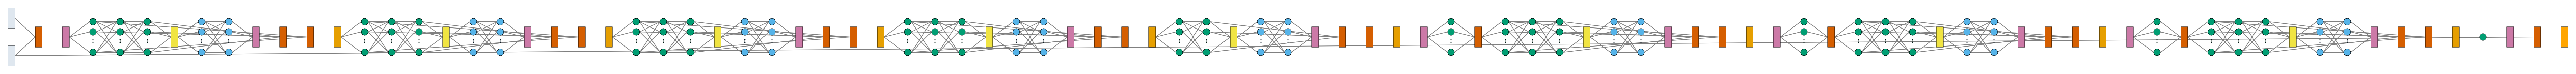

Diagrama guardado en: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams/cnn-v2_layered-diagram.png


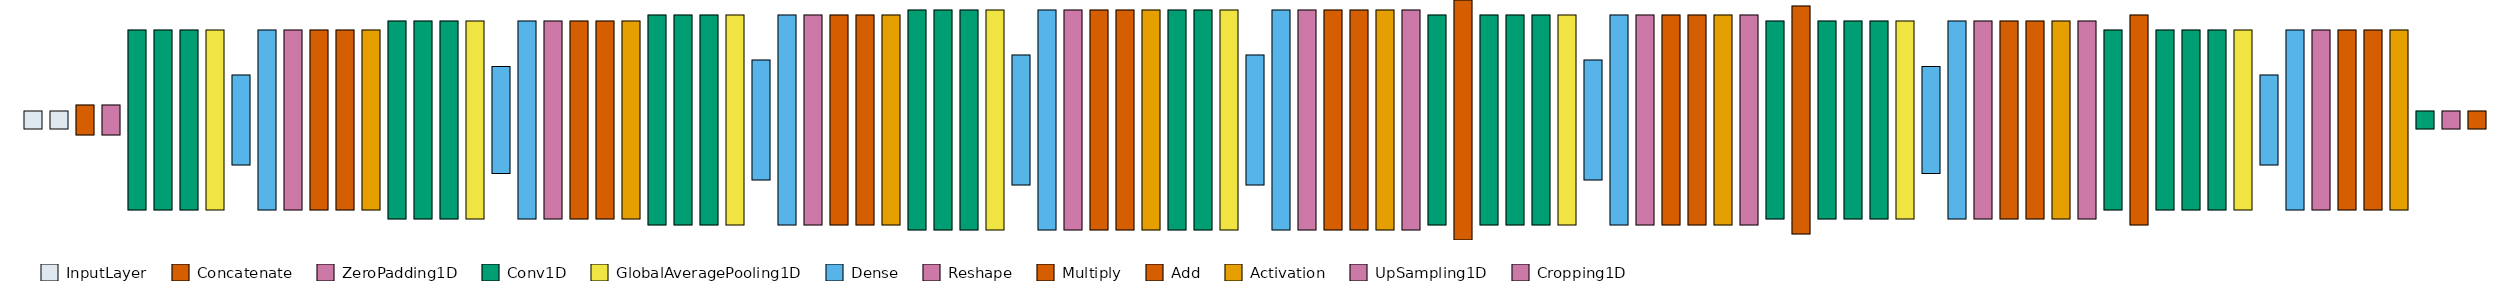

{'graph': PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams/cnn-v2_graph-diagram.png'),
 'layered': PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams/cnn-v2_layered-diagram.png')}

In [3]:
# Las 95 capas del modelo no caben en las figuras con las opciones comunes: con
# el hueco que estas dejan para el rótulo de cada capa, las vistas salen de más
# de diez mil píxeles de ancho. Son las únicas figuras del trabajo que
# necesitan retoque, así que se le pasa aquí y no al servicio.
draw_diagrams(
    model_cnn_v2, "cnn-v2"
  , views=("graph", "layered")
    # Sin los recuadros que rotulan cada capa ni la separación que piden sus
    # pies: con 95 capas, la figura saldría de más de veinte mil píxeles de
    # ancho y los pies, reducidos a una columna, no se leerían de todos modos
  , graph={
        "layer_spacing": 60, "node_size": 20, "ellipsize_after": 4
      , "layered_groups": [], "padding": 24
    }
    # Sin rotular y con las capas muy juntas: son 95, y sus formas, reducidas
    # al ancho de una página, saldrían en menos de dos puntos. El hueco no baja
    # de 8 porque es también el que la leyenda deja entre cada color y su texto
  , layered={"spacing": 8, "text_callable": None}
)